В цьому домашньому завданні кожне завдання оцінюється по 10 балів.

 **Завдання 1.** Після перегляду лекцій про поняття функії, вступ до лінійної алгебри і мат. формулювання лін. регресії знайдіть найкращу лінію для прогнозу `charges` за `age` **для некурців** (датафрейм `non_smoker_df`) з допомогою

1. Методу МНК (з використанням тільки `numpy`, без `scikit learn`)

2. Full-Batch градієнтного спуску з `numpy` . Протестуйте 3 різних learning rate і зробіть висновок, який є найкращим виходячи з практик для цього, наведених в лекції. Зверніть увагу, що на вхід треба набір даних дворозміний, для цього можливо треба буде трансформувати Ваші дані X в формат, як був в лекції "Математичне формулювання лінійної регресії". Також, градієнтний спуск в нашому випадку може розходитись з навчальним рейтом 0.1, бо цей рейт в цій задачі завеликий. Спробуйте нижчі рейти.
3. З `scikit-learn.LinearRegression`. Тут зверніть увагу, що вхід `X` має бути двовимірним масивом, тому нам потрібно передати dataframe, а не окрему колонку. Якщо у Вас X - колонка (а у Вас так мало б бути), то можна скористатись `X.to_frame()` щоб конвертувати колонку в датафрейм.

Для кожного методу
- знайдіть і виведіть коефіцієнти моделі
- обчисліть прогнози моделі і збережіть в окрему змінну
- порахуйте точність прогнозу RMSE  

Для градієнтного спуску виведіть графік помилки в залежності від ітерації.

А також побудуйте на одному графіку дані `age` проти `charges` в вигляді діаграми розсіювання і всі три лінії регресії, знайдені кожним з методів (для град. спуску оберіть варіант з тим learning rate, який виявився найкращим).

Зробіть висновки, чи відрізняються результати моделей?
Чи є знайдены параметри моделы близькими до ваших найкращих припущень?

In [93]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

medical_df = pd.read_csv('drive/MyDrive/medical-charges.csv') # замініть на ваш шлях до файлу
non_smoker_df = medical_df[medical_df.smoker == 'no']

In [95]:
non_smoker_df.head()

,age,sex,bmi,children,smoker,region,charges
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160


In [96]:
age = non_smoker_df[['age']].to_numpy()
charges = non_smoker_df['charges']

**1.1 МНК**

In [97]:
def normal_equations(x_fact,y_fact):
  param = np.linalg.inv(x_fact.T.dot(x_fact)).dot(x_fact.T).dot(y_fact)
  return param

In [98]:
age_with_intercept = np.c_[np.ones((age.shape[0], 1)), age]

In [99]:
# Коефіцієнти моделі
MNK_coefs = normal_equations(age_with_intercept,charges)
MNK_coefs

array([-2091.42055657,   267.24891283])

In [100]:
# Прогнозовані значення Y - charges - моделі (в окремій змінній)
MNK_charges_predicted = np.dot(age_with_intercept, MNK_coefs)

In [101]:
MNK_charges_predicted

array([2719.0598744 , 5391.54900271, 6727.79356686, ..., 2719.0598744 ,
       2719.0598744 , 3520.80661289])

In [102]:
# RMSE
def rmse(y_fact, y_pred):
    return np.sqrt(np.mean(np.square(y_fact - y_pred)))

In [103]:
MNK_rmse = rmse(charges, MNK_charges_predicted)
MNK_rmse

np.float64(4662.505766636395)

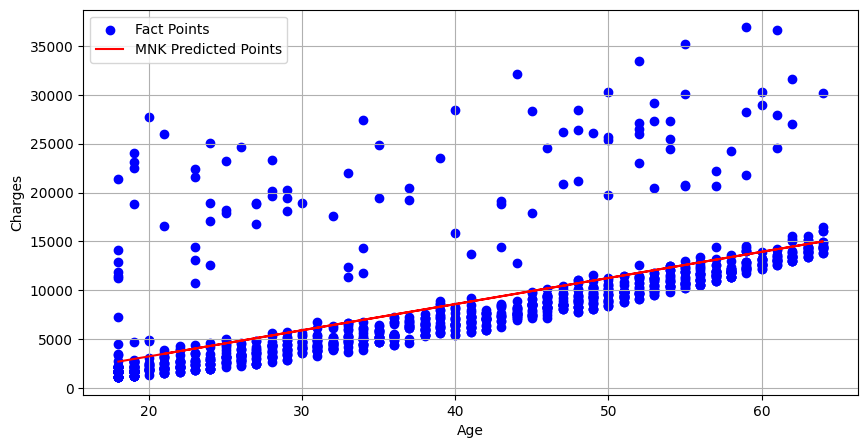

In [104]:
# Графік лінійної регресії
plt.figure(figsize=(10,5))
plt.scatter(age, charges, c='blue', label='Fact Points')
plt.plot(age, MNK_charges_predicted, color='red', label="MNK Predicted Points")
plt.xlabel('Age')
plt.ylabel('Charges')
plt.legend()
plt.grid(True)
plt.show()

**1.2 Full-Batch градієнтний спуск**

In [105]:
# lr > 0.001
def full_batch_gradient_descent(x, y, lr, epochs):
    m, b = 0.0, 0.0  # Початкові параметри
    n = len(y)
    errors = []
    for _ in range(epochs):
        y_pred = m * x[:, 0] + b
        error = y_pred - y
        print(sum(error))
        errors.append(sum(error**2))
        m_gradient = (2/n) * np.dot(error, x[:, 0])
        b_gradient = (2/n) * np.sum(error)
        m = m - lr * m_gradient
        b = b - lr * b_gradient
    return m, b, errors

m, b, errors = full_batch_gradient_descent(age, charges, 0.001, epochs=100)

-8974061.468919
23323533.092135303
-57436652.802540034
144503618.20617324
-360447295.03885174
902179926.8701692
-2255013798.713473
5639534302.364862
-14100746892.476397
35259734687.83188
-88165921289.37138
220459360133.36554
-551256728109.6649
1378415779249.3567
-3446721396099.907
8618511782483.983
-21550547949260.344
53887046303348.96
-134744309040298.1
336927522110359.9
-842485709034825.8
2106631617744203.2
-5267622610915094.0
1.3171665963707286e+16
-3.2935689789882016e+16
8.23555399115637e+16
-2.0592964645019834e+17
5.1492612801634496e+17
-1.2875704002987976e+18
3.2195638277546604e+18
-8.050504452864721e+18
2.0130249130921517e+19
-5.033559479974504e+19
1.2586392187031001e+20
-3.147221542051905e+20
7.869612902227623e+20
-1.9677930645622785e+21
4.920457452034665e+21
-1.2303581089543586e+22
3.076504757995173e+22
-7.692785910933556e+22
1.9235775572153572e+23
-4.8098967805196214e+23
1.2027124642036406e+24
-3.007376951225394e+24
7.519932149992567e+24
-1.8803555542796217e+25
4.701820362187

In [106]:
fbgd_charges_predicted = m * age[:, 0] + b

m, b

(np.float64(-1.3967624262082842e+42), np.float64(-3.1448925830775484e+40))

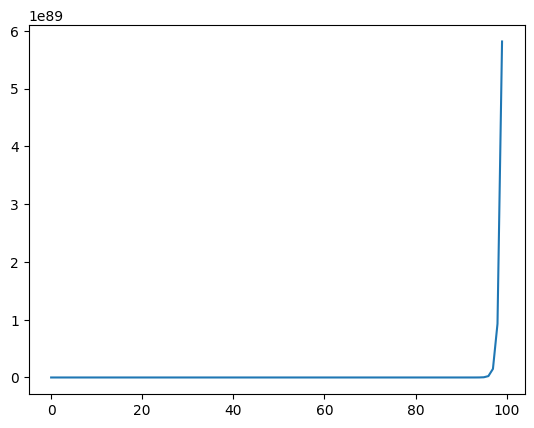

In [107]:
plt.plot(errors)

***ВИСНОВОК СПРОБА #1:***

Для lr > 0.001 виникає розбіжність. Відповідно помилки великі, скалярні добутки великі, градієнти великі (та збільшуються на кожному кроці, адже ми беремо на новій ітерації оновлений коефіцієнт). Зростаючий графік є підтвердженням.Відповідно, нам варто ще зменшити learning rate.

In [108]:
# lr = 0.0001
m_best, b_best, errors = full_batch_gradient_descent(age, charges, 0.0001, epochs=100)

-8974061.468919
-5744302.01281357
-3645120.361265437
-2280758.276915481
-1393992.5102562094
-817640.6912409419
-443042.5610946986
-199574.33434447486
-41334.04894114857
61512.29659010294
128355.32531343418
171797.98166234192
200031.555203354
218379.97838072653
230303.5435502358
238051.26932976057
243084.9064107147
246354.52033140173
248477.60662808394
249855.50681029508
250749.07297787495
251327.846073824
251702.01931249985
251943.2128245599
252097.97614707175
252196.56417318815
252258.6410847146
252296.9876257143
252319.91064670353
252332.80918901894
252339.19236207273
252341.34091315346
252340.73721501432
252338.34473650935
252334.78968466882
252330.47906303668
252325.6774037568
252320.55663961434
252315.2285184059
252309.7656706589
252304.21530261874
252298.60809600324
252292.96399241267
252287.29595289443
252281.6124014879
252275.9188134006
252270.21874724285
252264.51451593527
252258.80762276315
252253.0990447814
252247.3894170325
252241.67915225608
252235.9685187141
252230.257690

In [109]:
# Коефіцієнти моделі
m_best, b_best

(np.float64(220.15455659787733), np.float64(0.21295826871672194))

In [110]:
# Прогнозовані значення Y - charges - моделі (в окремій змінній)
fbgd_charges_predicted_best = m_best * age[:, 0] + b_best
fbgd_charges_predicted_best

array([3962.99497703, 6164.54054301, 7265.313326  , ..., 3962.99497703,
       3962.99497703, 4623.45864682])

In [111]:
# RMSE
fbgd_rmse = rmse(charges, fbgd_charges_predicted_best)
fbgd_rmse

np.float64(4715.349747703003)

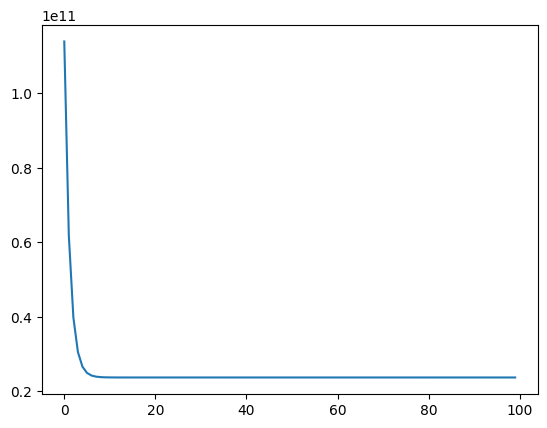

In [112]:
plt.plot(errors)

ДОСЛІДЖЕННЯ РІЗНИХ К-СТЕЙ ІТЕРАЦІЙ

In [113]:
m, b, errors = full_batch_gradient_descent(age, charges, 0.0001, epochs=1000)

-8974061.468919
-5744302.01281357
-3645120.361265437
-2280758.276915481
-1393992.5102562094
-817640.6912409419
-443042.5610946986
-199574.33434447486
-41334.04894114857
61512.29659010294
128355.32531343418
171797.98166234192
200031.555203354
218379.97838072653
230303.5435502358
238051.26932976057
243084.9064107147
246354.52033140173
248477.60662808394
249855.50681029508
250749.07297787495
251327.846073824
251702.01931249985
251943.2128245599
252097.97614707175
252196.56417318815
252258.6410847146
252296.9876257143
252319.91064670353
252332.80918901894
252339.19236207273
252341.34091315346
252340.73721501432
252338.34473650935
252334.78968466882
252330.47906303668
252325.6774037568
252320.55663961434
252315.2285184059
252309.7656706589
252304.21530261874
252298.60809600324
252292.96399241267
252287.29595289443
252281.6124014879
252275.9188134006
252270.21874724285
252264.51451593527
252258.80762276315
252253.0990447814
252247.3894170325
252241.67915225608
252235.9685187141
252230.257690

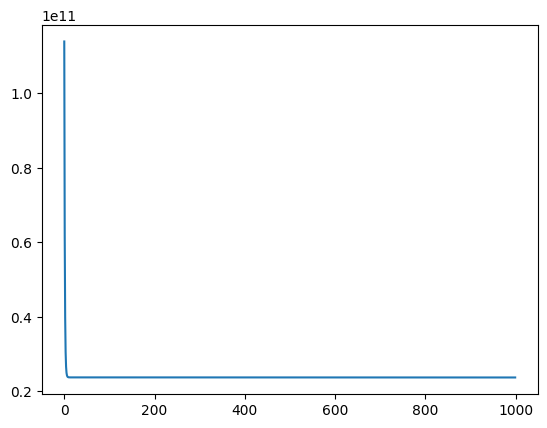

In [114]:
plt.plot(errors)

In [115]:
m, b, errors = full_batch_gradient_descent(age, charges, 0.0001, epochs=10000)

Streaming output truncated to the last 5000 lines.
225501.1427147446
225496.03664769314
225490.93069625864
225485.82486044007
225480.719140233
225475.6135356364
225470.5080466459
225465.40267326124
225460.2974154788
225455.1922732946
225450.08724670732
225444.982335715
225439.87754031492
225434.7728605014
225429.66829627572
225424.56384763317
225419.45951457124
225414.3552970896
225409.25119518116
225404.14720884766
225399.04333808436
225393.93958288984
225388.8359432589
225383.73241919192
225378.6290106846
225373.52571773515
225368.4225403398
225363.31947849758
225358.216532205
225353.11370145733
225348.01098625685
225342.90838659718
225337.80590247596
225332.7035338917
225327.6012808417
225322.4991433229
225317.39712133264
225312.2952148688
225307.19342392738
225302.0917485087
225296.99018860713
225291.88874422232
225286.7874153493
225281.68620198677
225276.58510413344
225271.4841217834
225266.3832549361
225261.28250358804
225256.18186773933
225251.08134738417
225245.98094252104
2252

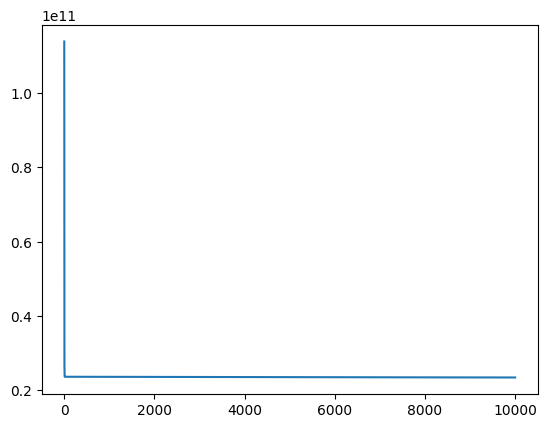

In [116]:
plt.plot(errors)

***ВИСНОВОК СПРОБА #2:***

Для lr = 0.0001 можна спостерігати зменшення помилки: різкий спад та помірно спадаючий "хвіст", який свідчить, що ф-ція витрат досягає мінімуму і модель попередньо добра. При збільшенні к-сті ітерацій до 1000, 10000, 100000 графік продовжує помірно спадати без різких коливань у "хвості", тобто lr не зависокий.

In [117]:
# lr = 0.00001
m, b, errors = full_batch_gradient_descent(age, charges, 0.00001, epochs=100)

-8974061.468919
-8651085.523308458
-8339415.355743487
-8038655.207986731
-7748423.175299615
-7468350.721501266
-7198082.211002769
-6937274.457222541
-6685596.286809409
-6442728.119120031
-6208361.560416696
-5982199.012270211
-5763953.293670629
-5553347.276365962
-5350113.532965861
-5153993.9973634025
-4964739.637043792
-4782110.136863892
-4605873.593901029
-4435806.222983608
-4271692.07252961
-4113322.7503321515
-3960497.1589439064
-3813021.240324387
-3670707.729425834
-3533375.916404818
-3400851.417157618
-3272965.9518879917
-3149557.131426181
-3030468.2510277964
-2915548.091390778
-2804650.7266377322
-2697635.3390198573
-2594366.0401071263
-2494711.6982377204
-2398545.7720075734
-2305746.149588614
-2216194.993671659
-2129778.5918370844
-2046387.2121632502
-1965914.9638893555
-1888259.6629557826
-1813322.7022511924
-1741008.9264016142
-1671226.5109425387
-1603886.8457205899
-1538904.4223767093
-1476196.725767992
-1415684.1291902885
-1357289.7932685455
-1300939.568386479
-1246561.90053

In [118]:
# Коефіцієнти моделі
m, b

(np.float64(213.82077107785156), np.float64(4.339426385055139))

In [119]:
# Прогнозовані значення Y - charges - моделі (в окремій змінній)
fbgd_charges_predicted = m * age[:, 0] + b
fbgd_charges_predicted

array([3853.11330579, 5991.32101656, 7060.42487195, ..., 3853.11330579,
       3853.11330579, 4494.57561902])

In [120]:
# RMSE
rmse(charges, fbgd_charges_predicted)

np.float64(4722.78331351864)

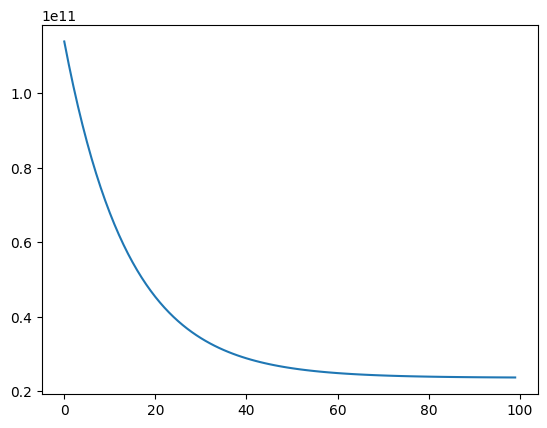

In [121]:
plt.plot(errors)

ДОСЛІДЖЕННЯ РІЗНИХ К-СТЕЙ ІТЕРАЦІЙ

In [122]:
m, b, errors = full_batch_gradient_descent(age, charges, 0.00001, epochs=1000)

-8974061.468919
-8651085.523308458
-8339415.355743487
-8038655.207986731
-7748423.175299615
-7468350.721501266
-7198082.211002769
-6937274.457222541
-6685596.286809409
-6442728.119120031
-6208361.560416696
-5982199.012270211
-5763953.293670629
-5553347.276365962
-5350113.532965861
-5153993.9973634025
-4964739.637043792
-4782110.136863892
-4605873.593901029
-4435806.222983608
-4271692.07252961
-4113322.7503321515
-3960497.1589439064
-3813021.240324387
-3670707.729425834
-3533375.916404818
-3400851.417157618
-3272965.9518879917
-3149557.131426181
-3030468.2510277964
-2915548.091390778
-2804650.7266377322
-2697635.3390198573
-2594366.0401071263
-2494711.6982377204
-2398545.7720075734
-2305746.149588614
-2216194.993671659
-2129778.5918370844
-2046387.2121632502
-1965914.9638893555
-1888259.6629557826
-1813322.7022511924
-1741008.9264016142
-1671226.5109425387
-1603886.8457205899
-1538904.4223767093
-1476196.725767992
-1415684.1291902885
-1357289.7932685455
-1300939.568386479
-1246561.90053

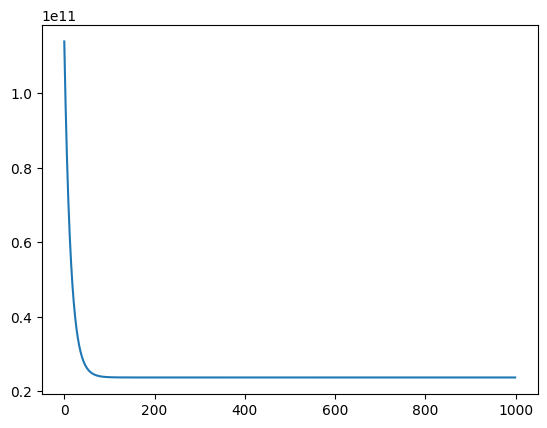

In [123]:
plt.plot(errors)

***ВИСНОВОК СПРОБА #3:***

Для lr = 0.00001 можна спостерігати зменшення помилки також. Однак графік показує, що на даній к-сті ітерацій можна побачити частину, де відбувається різкий спад, але не досягається моменту помірного спадання, коли ф-ція втрат наближена до свого мінімуму. З цього можна припустити, що к-сть ітерацій замала (при замалому learning rate графік від початку опускався повільно і був би майже горизонтальний). Провівши окремо дослідження з к-стю ітерацій = 1000, можна було спостерігати більш бажану форму: різкий спад та помірний спад на "хвості".

***ЗАГАЛЬНИЙ ВИСНОВОК***

Найкращий для моделі без зміни к-сті ітерацій є learning rate значення 0.0001.
Відповідно коефіцієнти моделі `(np.float64(220.15455659787733), np.float64(0.21295826871672194))`

**1.3 scikit-learn.LinearRegression**

In [124]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()

In [125]:
lin_reg.fit(age, charges)

LinearRegression()

In [126]:
# Коефіцієнти моделі
lin_reg.intercept_, lin_reg.coef_

(np.float64(-2091.4205565650864), array([267.24891283]))

In [127]:
# Прогнозовані значення Y - charges - моделі (в окремій змінній)
sklearn_charges_predicted = lin_reg.predict(age)
sklearn_charges_predicted

array([2719.0598744 , 5391.54900271, 6727.79356686, ..., 2719.0598744 ,
       2719.0598744 , 3520.80661289])

In [128]:
# RMSE
sklearn_rmse = rmse(charges, sklearn_charges_predicted)
sklearn_rmse

np.float64(4662.505766636395)

**РЕЗУЛЬТАТ**

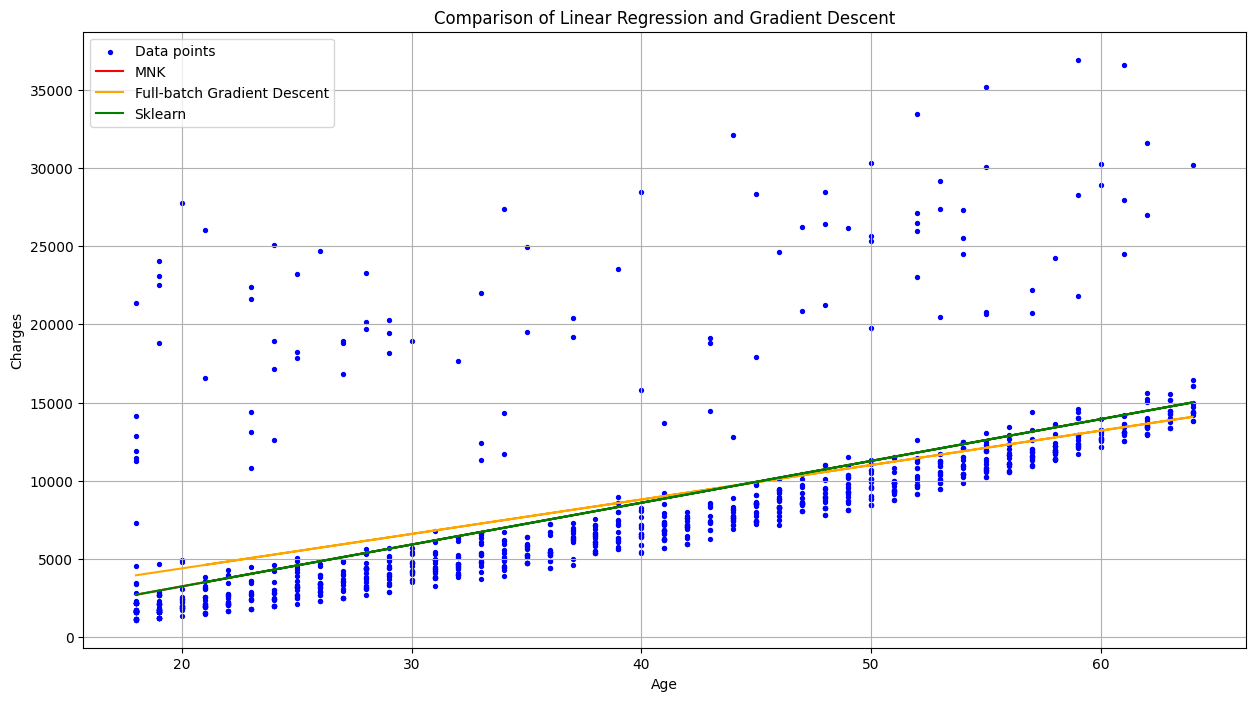

In [129]:
plt.figure(figsize=(15, 8))
plt.scatter(age[:, 0], charges, color='blue', s=8, label='Data points')
plt.plot(age[:, 0], MNK_charges_predicted, color='red', label='MNK')
plt.plot(age[:, 0], fbgd_charges_predicted_best, color='orange', label='Full-batch Gradient Descent')
plt.plot(age[:, 0], sklearn_charges_predicted, color='green', label='Sklearn')
plt.title('Comparison of Linear Regression and Gradient Descent')
plt.xlabel('Age')
plt.ylabel('Charges')
plt.legend()
plt.grid(True)
plt.show()

In [145]:
print('Коефіцієнти з МНК: ', MNK_coefs)
print('Коефіцієнти з повнопакетним град. спуском: ', b_best, m_best)
print('Коефіцієнти з sklearn: ', lin_reg.intercept_, lin_reg.coef_)

Коефіцієнти з МНК:  [-2091.42055657   267.24891283]
Коефіцієнти з повнопакетним град. спуском:  0.21295826871672194 220.15455659787733
Коефіцієнти з sklearn:  -2091.4205565650864 [267.24891283]


In [131]:
print('RMSE з МНК: ', MNK_rmse)
print('RMSE з повнопакетним град. спуском: ', fbgd_rmse)
print('RMSE з sklearn: ', sklearn_rmse)

RMSE з МНК:  4662.505766636395
RMSE з повнопакетним град. спуском:  4715.349747703003
RMSE з sklearn:  4662.505766636395


In [132]:
np.mean(charges), np.std(charges)

(np.float64(8434.268297856204), 5990.964530287611)

**ВИСНОВОК**

Відповідно до графіку лініціїї регресій співпадають для методів МНК та sklearn (що очікувано, адже бібліотека sklearn під капотом має саме МНК). Лінія регресії градієнтного спуску дещо більш горизонтальна, тобто має менший нахил, що підтверджує порівняння коефіцієнітів біля незалежної змінної `age`. Варто зазначити, що додатні коефіцієнти біля незалежної змінної свідчать про прямо порційну залежність `charges` від `age`.



За градієнтним спуском вільний член сильно вищий за інші моделі. Це може свідчити про те, що модель не досягла ще свого мінімуму. Або маленький lr, або недостатньо епох. Скоріш за все, друге, і к-сть епох варто збільшити зі 100, так як зараз модель ще не дійшла з цією к-стю ітерацій до оптимального мінімуму ф-ції втрат.

Середньоквадратична помилка в методі градієнтного спуску є дещо вища за інші методи, але в цілому несуттєво. При цьому гарною ознакою моделі є те, що середньоквадратичні помилки `rmse` є меншими за стандартне відхилення `std`. Тобто відхилення прогнозів від фактичних значень `charges` є меншим, ніж відхилення фактів від свого ж середнього.
Отже, моделі з даними методами роблять прогнози, які точніші, ніж якби використовувалось просте усереднення як прогнозний метод. Іншими словами, модель виявляє реальні закономірності в даних, а не просто запам'ятовує їх загальний розкид.

Загалом параметри всіх трьох моделей відповідають припущенням. На даному етапі дослідження моделі є доволі логічними та перспективними. Проте градієнтний спуск потребує доопрацювання задля більш оптимального результату.

 **Завдання 2.** Навчіть модель лінійної регресії з допомогою sklearn оцінювати розмір медичних збори для **курців** за їх віком.
Виведіть
- точність моделі
-  коефіцієнти
-  візуалізуйте модель у вигляді лінії на графіку розсіювання `age` проти `charges`

і зробіть висновки, чи це хороша модель, чи ви б її використовували в компанії?

In [133]:
smoker_df = medical_df[medical_df.smoker == 'yes']

age_smoker = smoker_df[['age']].to_numpy()
charges_smoker = smoker_df['charges']

In [134]:
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

In [135]:
lin_reg_smokers = LinearRegression()

In [136]:
lin_reg_smokers.fit(age_smoker, charges_smoker)

LinearRegression()

In [137]:
# Коефіцієнти моделі
lin_reg_smokers.intercept_, lin_reg_smokers.coef_

(np.float64(20294.128126915966), array([305.23760211]))

In [138]:
# Прогнозовані значення Y - charges - моделі (в окремій змінній)
charges_smokers_predicted = lin_reg_smokers.predict(age_smoker)
charges_smokers_predicted

array([26093.642567  , 39218.85945773, 28535.54338388, 29451.25619021,
       30672.20659865, 29756.49379232, 27009.35537333, 28840.78098599,
       30977.44420076, 38608.38425351, 31282.68180287, 34945.53302819,
       31282.68180287, 37997.90904929, 25788.40496489, 36471.72103874,
       26398.88016911, 28840.78098599, 28535.54338388, 27009.35537333,
       31587.91940498, 34029.82022186, 37692.67144718, 38303.1466514 ,
       39829.33466195, 37387.43384507, 31893.15700709, 38913.62185562,
       26398.88016911, 39524.09705984, 29146.0185881 , 33724.58261975,
       26093.642567  , 30061.73139443, 30672.20659865, 29451.25619021,
       34335.05782397, 33114.10741553, 34945.53302819, 25788.40496489,
       29451.25619021, 33114.10741553, 25788.40496489, 39524.09705984,
       31282.68180287, 28535.54338388, 30977.44420076, 26093.642567  ,
       33114.10741553, 32503.63221131, 26093.642567  , 27314.59297544,
       39524.09705984, 25788.40496489, 39524.09705984, 36776.95864085,
      

In [139]:
r2 = r2_score(charges_smoker, charges_smokers_predicted)
#Точність прогнозу моделі
rmse = root_mean_squared_error(charges_smoker, charges_smokers_predicted)
mae = mean_absolute_error(charges_smoker, charges_smokers_predicted)

print(f"R² score: {r2:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"Mean Absolute Error: {mae:.2f}")

R² score: 0.14
Root Mean Squared Error: 10711.00
Mean Absolute Error: 10097.80


In [140]:
np.mean(charges_smoker), np.std(charges_smoker), np.min(charges_smoker), np.max(charges_smoker)

(np.float64(32050.23183153284), 11520.466706529429, 12829.4551, 63770.42801)

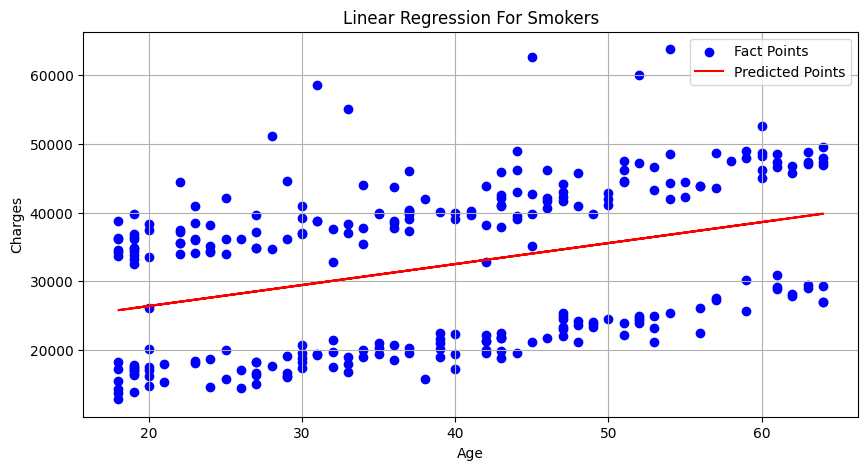

In [141]:
# Графік лінійної регресії
plt.figure(figsize=(10,5))
plt.scatter(age_smoker, charges_smoker, c='blue', label='Fact Points')
plt.plot(age_smoker, charges_smokers_predicted, color='red', label="Predicted Points")
plt.title('Linear Regression For Smokers')
plt.xlabel('Age')
plt.ylabel('Charges')
plt.legend()
plt.grid(True)
plt.show()

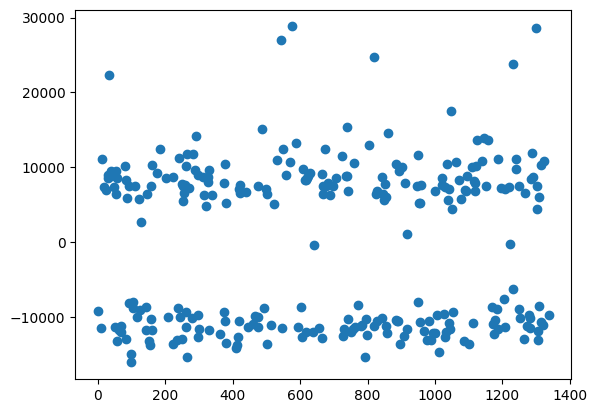

In [142]:
errors = charges_smoker - charges_smokers_predicted
plt.plot(errors, 'o');

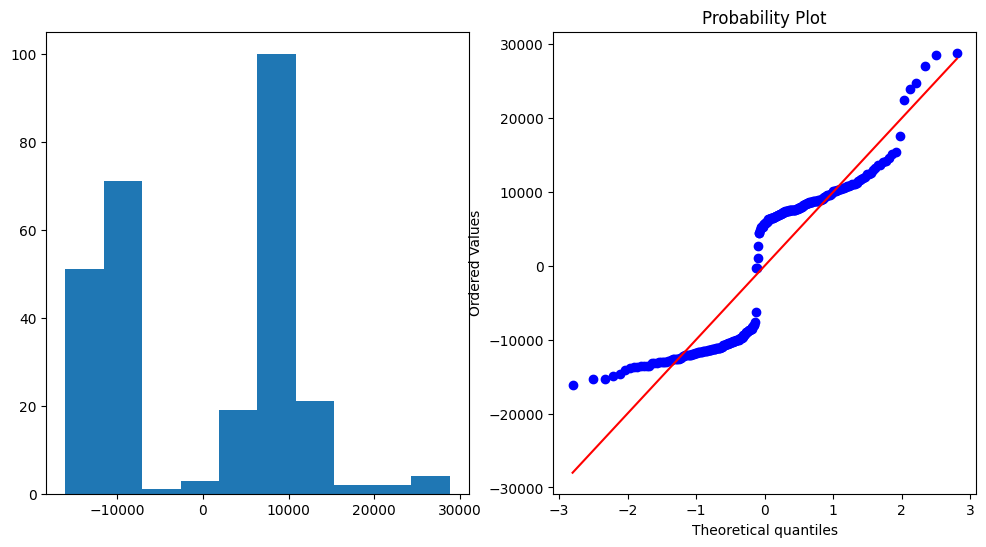

In [143]:
from scipy.stats import probplot

plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.hist(errors)
plt.subplot(1,2,2)
probplot(errors, dist='norm', plot=plt);

**ВИСНОВОК**

По-перше, отримане значення коефіцієнту детермінації = 0.14 означає, що модель пояснює лише близько 14% варіації страхових зборів. Це досить низький показник, близький до 0, тому `age` сам по собі є слабким предиктором зборів для курців.

Значення `rmse` = 10711 та `mae` = 10098 хоч і менші, але доволі близькі до `std` і також є великими порівняно із `mean` (близько 32050), тобто модель допускає значні похибки прогнозування.

Графік лінійної регресії показав, що точки фактичних значень не групуються навколо однієї прямої. Натомість спостерігаються дві окремі "хмари" даних, між якими проходить побудована регресійна пряма. Тобто, скоріш за все, для кожної вікової категорії існує кілька протилежних, різних між собою, показників страхових зборів, що не дає сформувати дані візуально на прямій. Це також імовірно означає, що існує ще один або декілька важливих факторів впливу на `charges`, але які не враховані моделлю.

Це підтверджується і аналізом залишків. Залишки також утворюють дві окремі групи. Гістограма залишків не нагадує нормальний розподіл, а QQ-графік демонструє суттєве відхилення від прямої, що свідчить про порушення припущення нормальності похибок.

У сукупності ці результати показують, що проста лінійна регресія з єдиною ознакою `age` не є адекватною моделлю для опису страхових зборів курців. Можливо, дані розподілені за іншим розподілом, а не гаусівським, або варто використати лінійну регресію багатьох змінних.